# Univariate LSTM model (Extracted Features)

**Directly predict *near-term* volatility (only) from return, historical volatility, and extracted features.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single ETF representing a market sector, using the ETF's daily returns and historical volatility as input along with a reduced set of features extracted from macroeconomic and other data.


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 5  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
train_pca_df = pd.read_csv(
    PCA_TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_pca_df = pd.read_csv(
    PCA_VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
# Combine PCA data with base data. From base data, select only return,
# historical volatility, and future volatility target.
train_df = pd.concat(
    [
        train_df[[TICKER + '_ret', TICKER + '_h-vol', TICKER + '_f-vol_target']],
        train_pca_df
    ],
    axis=1
)
val_df = pd.concat(
    [
        val_df[[TICKER + '_ret', TICKER + '_h-vol', TICKER + '_f-vol_target']],
        val_pca_df
    ],
    axis=1
)
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_f-vol_target']
train_df[data_cols + label_col]

,SPY_ret,SPY_h-vol,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_macro-5,PCA_indicies-1,PCA_indicies-2,PCA_indicies-3,PCA_indicies-4,SPY_f-vol_target
date,,,,,,,,,,,,,,
2015-10-22,0.016753,0.007990,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192,-0.027020,-0.035612,-0.031673,0.003920,-0.004416,0.008038
2015-10-23,0.010902,0.008700,-0.028761,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960,-0.000326,-0.024071,-0.030029,-0.043408,0.007682
2015-10-26,-0.002461,0.008729,-0.038998,-0.035716,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070,-0.043886,-0.037661,-0.007188,0.007669
2015-10-27,-0.001934,0.008519,0.011014,0.006914,0.076367,0.080811,0.070985,-0.022329,-0.023923,-0.006781,-0.033949,-0.052711,-0.068107,0.007657
2015-10-28,0.011310,0.009114,-0.069678,-0.046203,-0.056724,-0.043523,-0.030986,0.005244,0.009962,0.023684,0.088783,0.087957,0.062373,0.007253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,-0.000224,0.007469,-0.143119,-0.147170,-0.158972,-0.164089,-0.165783,-0.205792,-0.082340,-0.054542,0.063587,0.081313,0.008595,0.012897
2022-11-28,-0.016086,0.008508,-0.009138,0.052201,0.074293,0.078177,0.077974,-0.028327,-0.015203,-0.033317,-0.047889,-0.073258,-0.059011,0.012706
2022-11-29,-0.001719,0.008086,-0.153767,-0.197632,-0.167729,-0.112797,-0.078021,-0.137523,-0.152878,-0.046367,-0.021137,0.021585,0.059925,0.013284


In [3]:
val_df[data_cols + label_col]

,SPY_ret,SPY_h-vol,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_macro-5,PCA_indicies-1,PCA_indicies-2,PCA_indicies-3,PCA_indicies-4,SPY_f-vol_target
date,,,,,,,,,,,,,,
2023-01-03,-0.004219,0.010242,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311,0.337204,0.291585,0.291259,0.358576,0.305696,0.011025
2023-01-04,0.007691,0.010177,0.317675,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406,0.250842,0.217873,0.185065,0.198466,0.011143
2023-01-05,-0.011479,0.010796,0.206405,0.258067,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478,0.260471,0.297770,0.289716,0.010940
2023-01-06,0.022673,0.012081,0.382678,0.367219,0.349151,0.388915,0.363785,0.384096,0.367638,0.377479,0.353326,0.390000,0.430783,0.010161
2023-01-09,-0.000567,0.011195,0.401736,0.431695,0.521250,0.756041,0.699941,0.724333,0.684553,0.786744,0.791241,0.633941,0.517984,0.010439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,-0.002387,0.009243,0.329960,0.387138,0.362461,0.330073,0.330884,0.296511,0.139929,0.181070,0.182610,0.201420,0.195621,0.008510
2024-08-27,0.001372,0.007682,0.152327,0.150704,0.200752,0.162793,0.159418,0.108765,0.115386,0.132175,0.131496,0.134801,0.185632,0.008549
2024-08-28,-0.005822,0.007836,0.137624,0.144313,0.192165,0.154747,0.155202,0.120963,0.152945,0.166141,0.151012,0.094235,0.129049,0.008460


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 13])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 21, 13])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

An important tunable hyperparameter for the LSTM is the size of the hidden layer.  A larger number of neurons will increase model complexity and could lead to overfitting, while too few neurons would increase the model's bias.

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(13, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.001370833022519946
Validation loss: 0.007496592588722706
Epoch 20
Training loss:   0.0012441124999895692
Validation loss: 0.004692445509135723
Epoch 30
Training loss:   0.001634525484405458
Validation loss: 0.003959593363106251
Epoch 40
Training loss:   0.0016620506066828966
Validation loss: 0.0037963739596307278
Epoch 50
Training loss:   0.0019246141891926527
Validation loss: 0.0019212868064641953
Epoch 60
Training loss:   0.002152147237211466
Validation loss: 0.00016914820298552513
Epoch 70
Training loss:   0.0014745790977030993
Validation loss: 0.0009918594732880592
Epoch 80
Training loss:   0.001111036166548729
Validation loss: 0.002688982058316469
Epoch 90
Training loss:   0.004036889877170324
Validation loss: 0.0035195937380194664
Epoch 100
Training loss:   0.00708486745133996
Validation loss: 0.0013850261457264423


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


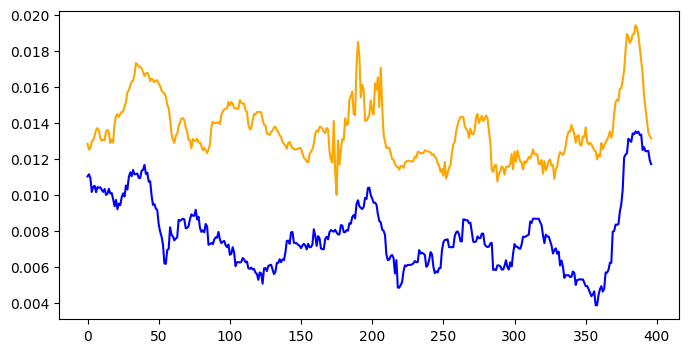

In [28]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds), color='orange')

It's not entirely clear whether the extracted features provide an overall benefit to the model.  Compared to the model with limited input (only return and volatility for the ETF in question), this model is less consistent.  Sometimes the forecast is very spot-on, but other times it misjudges what the market will do and goes in the wrong direction.  Whereas the limited-input model was consistently biased but also tracked consistently with the contours of future volatility figures.

In [26]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds) - 0.0058)}')

R2: 0.3206630349159241
MAE: 0.001276696566492319
RMSE: 0.0016230597393587232
MSE: 2.6343229819758562e-06
